# Project 3 - The Josephson Effect
Torjussen, P.; Schön, E. E.; Nielsen, L. V.; Borbe, N. G.

## Exercise 1

### 1a)
Given $\frac{d^2y}{dx^2}=-4\sin(2x), \hspace{3mm} y(0)=0, \hspace{3mm} y'(0)=2$ we define $(y_1,y_2)=(y,y')$. This gives the separable equation $\frac{dy_2}{dx}=-4\sin(2x),\hspace{3mm}y_2(0)=2$ which we solve by integration:
\begin{equation*}
    y_2(x)-y_2(0)=\int_0^x\frac{dy_2}{dx}dx=\int_0^x-4\sin(2x)dx=2\cos(2x)-2
\end{equation*}

\begin{equation*}
    \Rightarrow y'(x)=y_2(x)=2\cos(2x)-2+y_2(0)=2\cos(2x).
\end{equation*}

Repeating the process we get
\begin{equation*}
    y(x)=\int_0^xy'(x)dx+y(0)=\int_0^x2\cos(2x)dx=\underline{\sin(2x)}.
\end{equation*}

### 1b)
Write $\vec{y}(x) =(y(x),y^\prime(x))=(y_1(x),y_2(x))$. Then, $\frac{d}{dx}\vec{y}(x)=(y'(x),y''(x))=(y_2(x),-4\sin(2x))$. The differential equation becomes

\begin{equation*}
    \frac{d}{dx}(y_1,y_2) = (y_2,-4\sin2x),\hspace{3mm} \vec{y}(0) = (0,2).
\end{equation*}

### 1c)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_bvp, simpson
import tqdm # For progress bars
from IPython.display import Image

plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.grid': True,
    'lines.linewidth': 0.8,
    'figure.figsize': (9,5),
})

In [3]:
# Oppgave 1c)
def f(x, y):
    # The differential equation
    y_1, y_2 = y
    dy = [y_2, -4*np.sin(2*x)]
    return np.array(dy)

def BogackiShampine(x_init, x_end, y_init, f, h0, tol, alpha):
    x_n = x_init
    y_n = y_init

    X = [x_n]
    Y = [y_n.copy()]
    H = [h0]
    n_accept = 0
    n_reject = 0
    h = h0

    k1 = f(x_n, y_n)

    while x_end - x_n > 0:
        h = min(h, x_end - x_n)
        k2 = f(x_n + h / 2, y_n + h * k1 / 2)
        k3 = f(x_n + 3 * h / 4, y_n + 3 * h * k2 / 4)
        y_n1 = y_n + h * (2 * k1 + 3 * k2 + 4 * k3) / 9
        x_n1 = x_n + h
        k4 = f(x_n + h, y_n1)
        z_n1 = y_n + h * (7 * k1 + 6 * k2 + 8 * k3 + 3 * k4) / 24
        est = np.linalg.norm(y_n1 - z_n1)

        if est < tol:
            x_n = x_n1
            y_n = y_n1
            k1 = k4

            X.append(x_n)
            Y.append(y_n.copy())
            H.append(h)
            n_accept += 1

        else:
            n_reject += 1

        # Update the step length
        if est > 0: # To avoid a singularity
          h = alpha * h * ((tol / est)**(1/3))
        else:
          h = h0

    stats = {
        'n_accept': n_accept,
        'n_reject': n_reject,
        'final_step_length': h
    }

    return np.array(X), np.array(Y), np.array(H), stats

In [4]:
alpha = 0.8
tol = 1e-7
y_init = np.array([0, 2])
x_init = 0
x_end = 2 * np.pi
h0 = 0.005

X, Y, H, stats = BogackiShampine(x_init, x_end, y_init, f, h0, tol, alpha)

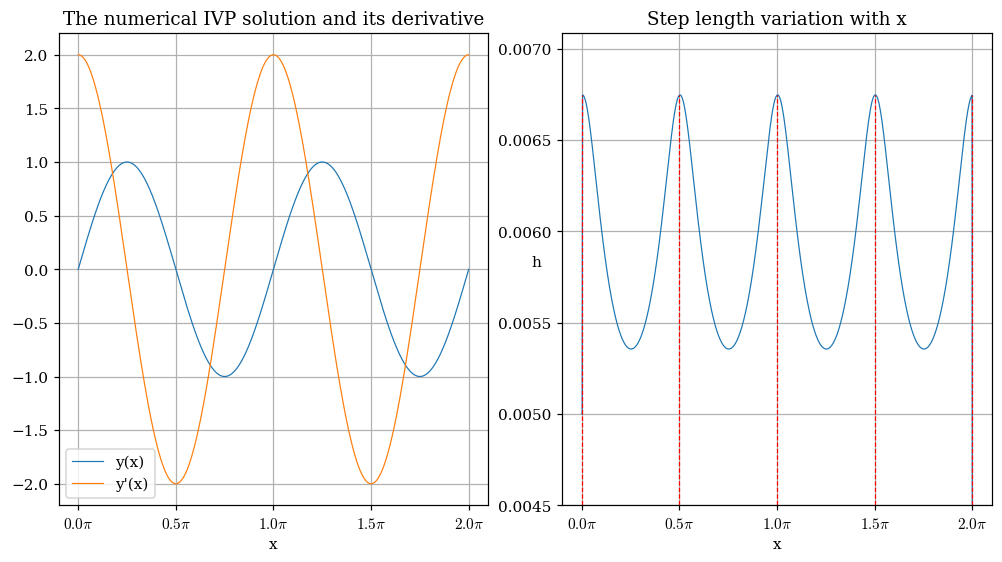

In [5]:
# Plotting y(x) and y'(x)
fig = plt.figure(constrained_layout = True)
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(X, Y[:, 0], label='y(x)')
ax1.plot(X, Y[:, 1], label="y'(x)")
ax1.set_xlabel('x')
ax1.set_title('The numerical IVP solution and its derivative')
ax1.legend()

# Plotting the step size h
ax2.plot(X, H, label='Step length h')
ax2.set_xlabel('x')
ax2.set_ylabel('h', rotation = 'horizontal', labelpad = -25)
ax2.set_title('Step length variation with x')
ax2.vlines(np.arange(0, 2*np.pi+np.pi/2, np.pi/2), ymin=0, ymax=np.max(H), color = 'r', linestyle='--')
ax2.set_ylim(bottom=0.0045)

ticks = np.arange(0, 2*np.pi + np.pi/2, np.pi/2)
labels = [f'${num/np.pi}\\pi$' for num in ticks]
ax1.set_xticks(ticks, labels)
ax2.set_xticks(ticks, labels)
plt.show()

The step length varies in accordance with the estimated local error (est) of the IVP solver. When the error is higher, the step length is decreased to increase the solver's accuracy. Conversely, the step length is increased when the error is low and the precision can be decreased. We see that the step length varies periodically, peaking at intervals of $π/2$. Vertical dashed lines are plotted at intervals of $\pi/2$ to illustrate this. The minima of the step lengths correspond to the maxima and minima of y. This is where the curvature of y is highest, and thus where a higher precision is needed. Between its maxima, y is almost linear and a higher step length can be used.

### 1d)

In [6]:
alpha = 0.8
tol = 1e-7
y_init = np.array([0, 2])
x_init = 0
x_end = 2 * np.pi
h0 = 0.005

# Find the real error as a function of tolerance
tol_array = np.linspace(1e-8,1e-1,100)
err_array = np.zeros(len(tol_array))

for i,tol in enumerate(tol_array):
    X, Y, H, stats = BogackiShampine(x_init, x_end, y_init, f, h0, tol, alpha)
    # Take the mean square error
    err_array[i] = np.mean((np.sin(2*X) - Y[:,0])**2)


# Find the number of time steps as a function of alpha, at tolerance 1e-7
tol = 1e-7

alpha_array = np.linspace(0.1, 0.9, 100)
step_number_array = np.zeros(len(alpha_array))
for i, alpha in enumerate(alpha_array):
    X, Y, H, stats = BogackiShampine(x_init, x_end, y_init, f, h0, tol, alpha)
    n_steps = stats['n_accept'] + stats['n_reject']
    step_number_array[i] = n_steps

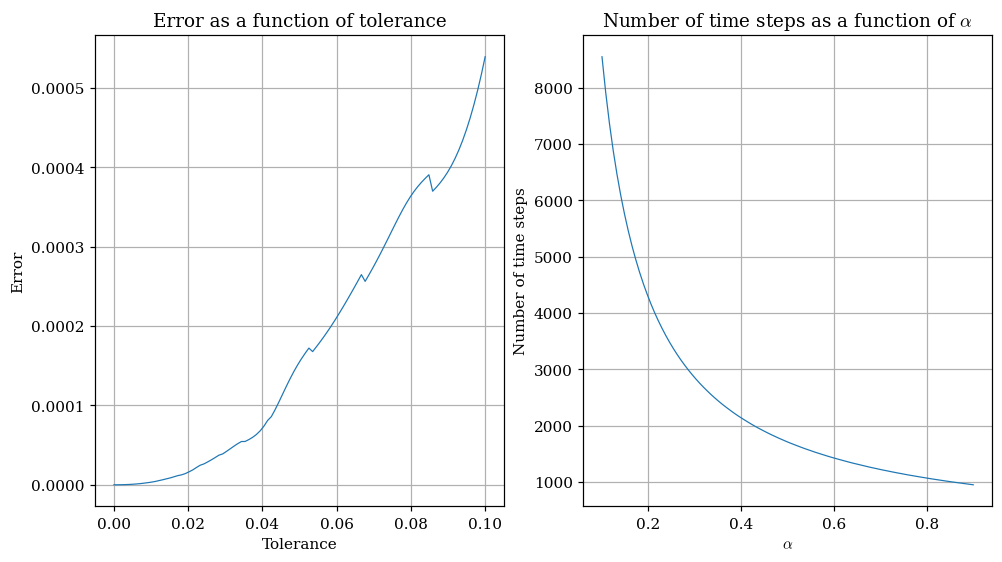

In [7]:
fig2 = plt.figure(constrained_layout = True)
ax21 = fig2.add_subplot(121)
ax22 = fig2.add_subplot(122)

ax21.plot(tol_array, err_array)
ax21.set_title("Error as a function of tolerance")
ax21.set_ylabel("Error")
ax21.set_xlabel("Tolerance")

ax22.plot(alpha_array, step_number_array)
ax22.set_title("Number of time steps as a function of $\\alpha$")
ax22.set_xlabel("$\\alpha$")
ax22.set_ylabel("Number of time steps")

plt.show()

As expected, the error increases with the tolerance. This suggests that the estimated error is a good indicator of the real error, as the tolerance denotes how large of an estimated error we accept.

From the expression for the updated step length it is evident that the new step length increases with $\alpha$. This means the number of steps should decrease with $\alpha$, as seen in the figure above. However, if $\alpha$ is too large, we expect more steps to be rejected thus leading to an increase in the number of steps. The plot above does not show this effect, because the solver doesn't discard any steps, even for $\alpha=0.9$. A more complicated equation would likely lead to more discarded steps. The amount of discarded steps is shown below.

In [8]:
print(stats['n_reject'])

0


### 1e)

In [9]:
def root_finder(func, guess1:float, guess2:float, tol:float, params:tuple=(), max_iter:float=1e6)->np.ndarray:
    '''
    Finds the approximate root of a function using the secant method and saves the solution for each iteration.
    Parameters:
        func: A scalar function whose root is to be found
        guess: Initial guesses for the root
        tol: The difference between the current and last iteration. A lower number corresponds to a higher precision.
        params (optional): Extra arguments to be passed to the function
        max_iter: Maximum amount of iterations, prevents infinite while loop
    Returns:
        An array containing the approximated roots for each iteration
    '''

    z_0, z_1 = guess1, guess2
    g_0, g_1 = func(z_0, *params), func(z_1, *params)

    diff = 1000
    iterations = 0
    root_vals = [z_0, z_1]
    while diff >= tol:
        z_new = (z_0*g_1 - z_1*g_0)/(g_1 - g_0)     # The secant method
        diff = np.abs(z_new-z_1)

        # Update the parameters
        z_0 = z_1
        z_1 = z_new
        g_0, g_1 = func(z_0, *params), func(z_1, *params)

        root_vals.append(z_1)

        iterations += 1
        if iterations > max_iter:
            print('Max iterations exceeded')
            return np.array([])

    return np.array(root_vals)

def g(z):
    return z + np.sin(z) + np.cos(z)

print(root_finder(g, -2, 2, 1e-5)[-1])

-0.4566247045676134


Using the python function to find the root of $g(z)=z+\sin(z)+\cos(z)$ we find that $z\approx-0.45662$. This corresponds with the solution obtained graphically using GeoGebra.

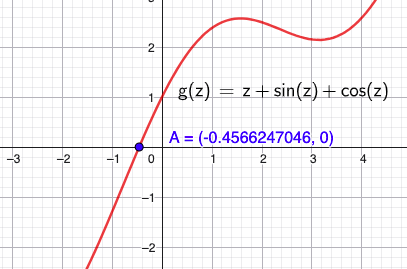

In [10]:
Image('Geog.png')

### 1f)

In [11]:
def F(b:float, f, y_left:float, y_right:float, x_left:float, x_right:float, h0:float, alpha:float, tol:float)->float:
    '''
    Solves the IVP and evaluates the error of the solution at the right boundary.
    Parameters:
        b: y'(0)
        f: The right side of the differential equation
        y_left: The boundary value at the start of the interval
        y_right: The boundary value at the end of the interval
        x_left: The left boundary
        x_right: The right boundary
        h0: The initial step size for the IVP solver
        alpha: Optimism parameter for dynamic step size adjustment
        tol: The tolerated error of the IVP solver
    Returns:
        The error of the solution at the right boundary
    '''
    y_init = np.array([y_left, b])
    Y = BogackiShampine(x_left, x_right, y_init, f, h0, tol, alpha)[1]
    y_right_approx = Y[-1,0]
    err = abs(y_right_approx - y_right)
    return err

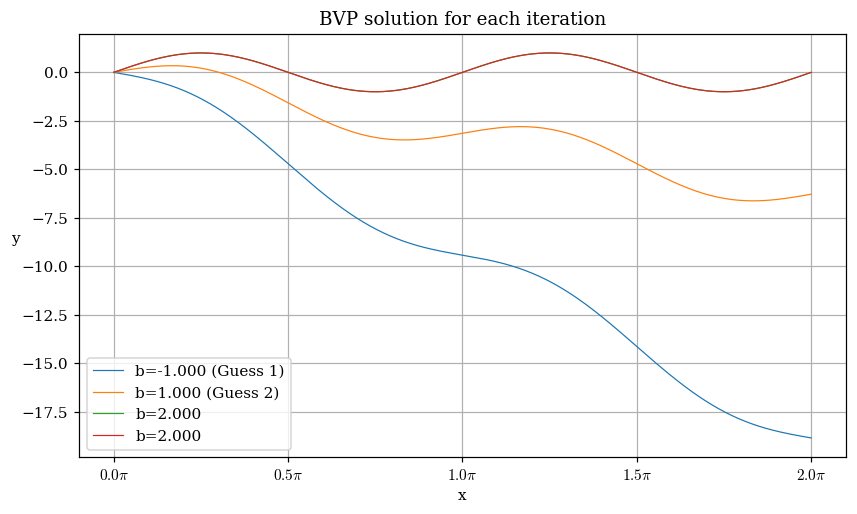

In [12]:
alpha = 0.8
tol = 1e-7
h0 = 0.01
x_left = 0
x_right = 2 * np.pi
y_left = 0
y_right = 0
b1 = -1
b2 = 1

# Minimize F
args = (f, y_left, y_right, x_left, x_right, h0, alpha, tol)
b_list = root_finder(F, b1, b2, tol, params = args)

# Plot the solution for each iteration of the solver
for i, b in enumerate(b_list):
    y_init = np.array([y_left, b])
    X, Y, H, stats = BogackiShampine(x_left, x_right, y_init, f, h0, tol, alpha)
    solution = Y[:,0]

    if i==0:
        lab = f'b={b:.3f} (Guess 1)'
    elif i==1:
        lab = f'b={b:.3f} (Guess 2)'
    else:
        lab = f'b={b:.3f}'

    plt.plot(X, solution, label = lab)

plt.xlabel('x')
plt.ylabel('y', rotation = 'horizontal')
plt.legend()
plt.title('BVP solution for each iteration')

ticks = np.arange(0, 2*np.pi+np.pi/2, np.pi/2)
ticklabels = [f'${tick/np.pi}\\pi$' for tick in ticks]
plt.xticks(ticks, ticklabels)

plt.show()

The solver converges on its first iteration. We note that all the different solutions have the correct value at the left boundary, but different initial derivatives which makes their value at the right boundary different. The final iteration satisfies both boundary conditions.

### 1g)
Given $y''(x)=y(x)+\sin(x), \hspace{3mm} y(0)=y(12)=0$ (eq. 7) we get the following set of first order ODEs:
$\frac{d}{dx}(y_1,y_2)=(y_2,y_1+sin(x))$.

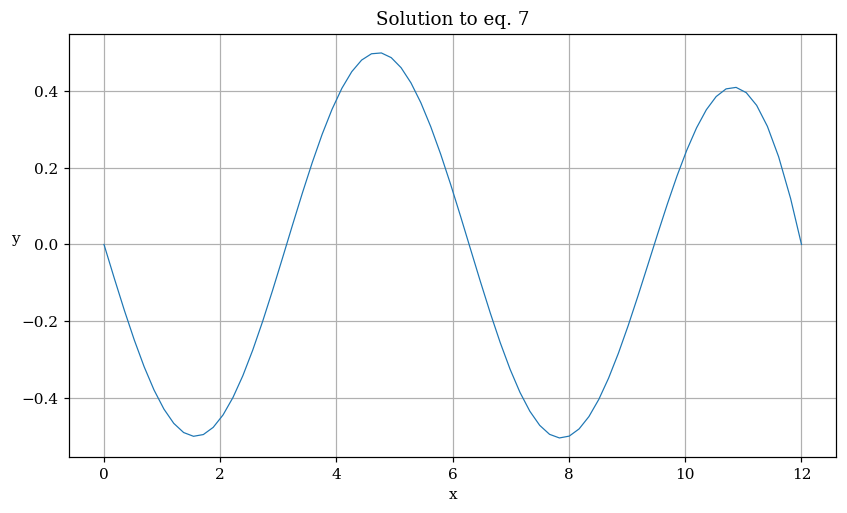

In [13]:
def g(x, y):
    y_1, y_2 = y
    dy = [y_2, y_1 + np.sin(x)]

    return np.array(dy)

alpha = 0.8
tol = 1e-4
h0 = 0.01
x_left = 0
x_right = 12
y_left = 0
y_right = 0
b1 = -1
b2 = 1

# Minimize F to find the initial derivative b
args = (g, y_left, y_right, x_left, x_right, h0, alpha, tol)
b_list = root_finder(F, b1, b2, tol, params = args)
y_init = np.array([y_left, b_list[-1]])

# Plot the solution
X, Y, H, stats = BogackiShampine(x_left, x_right, y_init, g, h0, tol, alpha)
y_sol = Y[:,0]

plt.plot(X, y_sol)
plt.xlabel('x')
plt.ylabel('y', rotation = 'horizontal')
plt.title('Solution to eq. 7')
plt.show()

The solution satisfies the boundary conditions given in equation 7. For this problem the solver converges more slowly, and as a result the tolerance has been increased.

### 1h)


In [14]:
def bc_residuals(y_left:np.ndarray, y_right:np.ndarray)->np.ndarray:
    # The solution should be zero at both boundaries, so the residuals equal the value of the function
    res_left = y_left[0]
    res_right = y_right[0]

    return np.array([res_left, res_right])

In [15]:
# Solve the BVP
x = np.linspace(0, 12, 200)
y_guess = np.zeros((2, 200))
scipy_solution = solve_bvp(g, bc_residuals, x, y_guess)
Y = scipy_solution.sol(X)
y = Y[0,:]

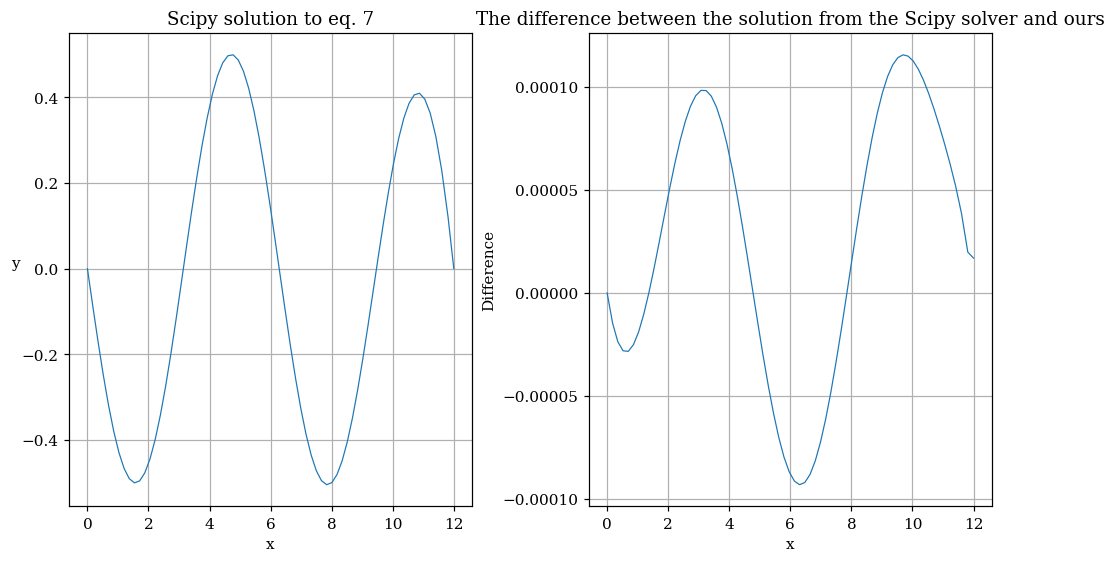

In [16]:
# Plotting
fig2 = plt.figure(constrained_layout = True)
ax31 = fig2.add_subplot(121)
ax32 = fig2.add_subplot(122)

ax31.plot(X, y)
ax31.set_xlabel("x")
ax31.set_ylabel("y", rotation = 'horizontal')
ax31.set_title("Scipy solution to eq. 7")

diff = y - y_sol
ax32.plot(X, diff)
ax32.set_xlabel("x")
ax32.set_ylabel("Difference")
ax32.set_title("The difference between the solution from the Scipy solver and ours")
plt.show()

The difference between the solutions is very small, as shown in the figure to the right. While the difference oscillates as a function of x, its maxima increase with x. This shows how the error accumulates for each step. The main advantage of the Scipy solver over ours is the runnning time. We had to increase the tolerance of our solver, decreasing its accuracy, to reduce the running time. Even with a higher tolerance our solver is slower than the Scipy solver, making Scipy the preferred alternative.

## Exercise 2

### 2a)

In [17]:
# Not in use: here for legacy
def old_transform_matrix_to_vector(M):
    """
    Transforming a 2x2 complex matrix M into a real vector m.
    """
    m = []
    real = np.real(M)
    imag = np.imag(M)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            m.append(real[i][j])

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            m.append(imag[i][j])

    return np.array(m)

# New
def transform_matrix_to_vector(M: np.ndarray):
    real = np.real(M)
    imag = np.imag(M)
    return np.concatenate([real.flatten(), imag.flatten()])


def transform_vector_to_matrix(m):
    """
    Transforms a real vector m back into a 2x2 complex matrix M.
    """
    n = len(m) // 2
    M = np.zeros((2, 2))
    real = m[:n]
    imag = m[n:]

    M = real + 1j * imag
    return M.reshape((2, 2))

In [18]:
M = np.array([[1 + 2j, 3 + 4j],
              [6 + 9j, 7 + 8j]])

m = transform_matrix_to_vector(M)
print("Vector m:\n", m)

M_reconstructed = transform_vector_to_matrix(m)
print("Reconstructed Matrix M:\n", M_reconstructed)

Vector m:
 [1. 3. 6. 7. 2. 4. 9. 8.]
Reconstructed Matrix M:
 [[1.+2.j 3.+4.j]
 [6.+9.j 7.+8.j]]


Using an example matrix M we see that the functions work correctly. Applying the first function followed by its inverse returns the original input M, which shows that the functions are indeed inverses.

### 2b)

In [19]:
def transform_four_8comp_vectors_to_32comp_vector(m1, m2, m3, m4):
    """
    Transforms four 8-component real vectors into a single 32-component real vector v.
    """
    return np.concatenate((m1, m2, m3, m4))

# Here for legacy
def old_transform_32comp_vector_to_four_8comp_vectors(v):
    """
    Transforming a 32-component real vector v back into four 8-component real vectors.
    """
    m1 = v[:8]
    m2 = v[8:16]
    m3 = v[16:24]
    m4 = v[24:32]
    return m1, m2, m3, m4

def transform_32comp_vector_to_four_8comp_vectors(v):
    """
    Transforms a 32-component real vector v back into four 8-component real vectors.
    """
    return v[:8], v[8:16], v[16:24], v[24:32]

In [20]:
m1 = np.array([1, 2, 3, 4, 5, 6, 7, 8])
m2 = np.array([9, 10, 11, 12, 13, 14, 15, 16])
m3 = np.array([17, 18, 19, 20, 21, 22, 23, 24])
m4 = np.array([25, 26, 27, 28, 29, 30, 31, 32])

v = transform_four_8comp_vectors_to_32comp_vector(m1, m2, m3, m4)
print("Vector v:\n", v)

m1_reconstructed, m2_reconstructed, m3_reconstructed, m4_reconstructed = transform_32comp_vector_to_four_8comp_vectors(v)
print("Reconstructed m1:", m1_reconstructed)
print("Reconstructed m2:", m2_reconstructed)
print("Reconstructed m3:", m3_reconstructed)
print("Reconstructed m4:", m4_reconstructed)

Vector v:
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32]
Reconstructed m1: [1 2 3 4 5 6 7 8]
Reconstructed m2: [ 9 10 11 12 13 14 15 16]
Reconstructed m3: [17 18 19 20 21 22 23 24]
Reconstructed m4: [25 26 27 28 29 30 31 32]


Using four example vectors we test the code in the same way as in 2a) and verify that it works as intended.

### 2c)

In [21]:
def transform_matrices_to_32comp_vector(gamma, gamma_tilde, omega, omega_tilde):
    """
    Transforms four unknown 2x2 complex matrices into a single 32-component real vector v.
    """
    # Transform each matrix to an 8-component real vector
    m_gamma = transform_matrix_to_vector(gamma)
    m_gamma_tilde = transform_matrix_to_vector(gamma_tilde)
    m_omega = transform_matrix_to_vector(omega)
    m_omega_tilde = transform_matrix_to_vector(omega_tilde)

    # Transform the four 8-component vectors into a single 32-component vector
    v = transform_four_8comp_vectors_to_32comp_vector(m_gamma, m_gamma_tilde, m_omega, m_omega_tilde)

    return v

def transform_32comp_vector_to_matrices(v):
    """
    Transforms a 32-component real vector v into four 2x2 complex matrices.
    """
    # Transform the 32-component vector back to four 8-component vectors
    m_gamma, m_gamma_tilde, m_omega, m_omega_tilde = transform_32comp_vector_to_four_8comp_vectors(v)

    # Transform each 8-component vector back to a 2x2 complex matrix
    gamma = transform_vector_to_matrix(m_gamma)
    gamma_tilde = transform_vector_to_matrix(m_gamma_tilde)
    omega = transform_vector_to_matrix(m_omega)
    omega_tilde = transform_vector_to_matrix(m_omega_tilde)

    return gamma, gamma_tilde, omega, omega_tilde

In [22]:
gamma = np.array([[1 + 1j, 2 + 2j],
              [3 + 3j, 4 + 4j]])
gamma_tilde = np.array([[5 + 5j, 6 + 6j],
              [7 + 7j, 8 + 8j]])
omega = np.array([[9 + 9j, 10 + 10j],
              [11 + 11j, 12 + 12j]])
omega_tilde = np.array([[13 + 13j, 14 + 14j],
              [15 + 15j, 16 + 16j]])

v = transform_matrices_to_32comp_vector(gamma, gamma_tilde, omega, omega_tilde)
print("Vector v:\n", v)

gamma_reconstructed, gamma_tilde_reconstructed, omega_reconstructed, omega_tilde_reconstructed = transform_32comp_vector_to_matrices(v)
print("Reconstructed gamma:\n", gamma_reconstructed)
print("Reconstructed gamma_tilde:\n", gamma_tilde_reconstructed)
print("Reconstructed omega:\n", omega_reconstructed)
print("Reconstructed omega_tilde:\n", omega_tilde_reconstructed)


Vector v:
 [ 1.  2.  3.  4.  1.  2.  3.  4.  5.  6.  7.  8.  5.  6.  7.  8.  9. 10.
 11. 12.  9. 10. 11. 12. 13. 14. 15. 16. 13. 14. 15. 16.]
Reconstructed gamma:
 [[1.+1.j 2.+2.j]
 [3.+3.j 4.+4.j]]
Reconstructed gamma_tilde:
 [[5.+5.j 6.+6.j]
 [7.+7.j 8.+8.j]]
Reconstructed omega:
 [[ 9. +9.j 10.+10.j]
 [11.+11.j 12.+12.j]]
Reconstructed omega_tilde:
 [[13.+13.j 14.+14.j]
 [15.+15.j 16.+16.j]]


We create examples of the vectors and see that the code works as intended. The matrices are vectorized into $\vec{v}$ in the following way, where $z_r$ and $z_i$ denote Re($z$) and Im($z$) respectively:

$$\vec{v}=(𝛄_{11r}, 𝛄_{12r}, 𝛄_{21r}, 𝛄_{22r}, 𝛄_{11i}, 𝛄_{12i}, 𝛄_{21i}, 𝛄_{22i},$$


$$\hspace{10mm} \tilde{𝛄}_{11r}, \tilde{𝛄}_{12r}, \tilde{𝛄}_{21r}, \tilde{𝛄}_{22r}, \tilde{𝛄}_{11i}, \tilde{𝛄}_{12i}, \tilde{𝛄}_{21i}, \tilde{𝛄}_{22i},$$

$$\hspace{12mm} 𝛚_{11r}, 𝛚_{12r}, 𝛚_{21r}, 𝛚_{22r}, 𝛚_{11i}, 𝛚_{12i}, 𝛚_{21i}, 𝛚_{22i},$$

$$\hspace{12mm} \tilde{𝛚}_{11r}, \tilde{𝛚}_{12r}, \tilde{𝛚}_{21r}, \tilde{𝛚}_{22r}, \tilde{𝛚}_{11i}, \tilde{𝛚}_{12i}, \tilde{𝛚}_{21i}, \tilde{𝛚}_{22i})$$


### 2d)

In [23]:
def calculate_Ns(gamma, gamma_tilde):
    """
    Helper function to calculate the matricies N and Ñ.
    """
    I = np.identity(2)

    N = np.linalg.inv(I - (gamma @ gamma_tilde))
    N_tilde = np.linalg.inv(I - (gamma_tilde @ gamma))

    return N, N_tilde


def dv(v:np.ndarray, epsilon:float)->np.ndarray:
    '''
    Computes the derivative of the 32 component vector v wrt. x.
    '''
    gamma, gamma_tilde, omega, omega_tilde = transform_32comp_vector_to_matrices(v)

    # Gamma and gamma_tilde have trivial derivatives
    d_gamma, d_gamma_tilde = omega, omega_tilde

    N, N_tilde = calculate_Ns(gamma, gamma_tilde)

    # The derivatives of omega and omega_tilde
    d_omega = -2j*(epsilon + 0.01j)*gamma - 2*omega @ N_tilde @ gamma_tilde @ omega
    d_omega_tilde = -2j*(epsilon + 0.01j)*gamma_tilde - 2*omega_tilde @ N @ gamma @ omega_tilde

    dv = transform_matrices_to_32comp_vector(d_gamma, d_gamma_tilde, d_omega, d_omega_tilde)

    return dv

### 2e)

In [24]:
# Not in use (here for legacy)
def h_old(x: np.ndarray, vec: np.ndarray, epsilon:float=1) -> np.ndarray:
    """
    The right hand side of the differential equation
    Parameters:
        x: Vector with m components
        vec: 32 x m matrix that contains the vector v at each position in x

    Returns:
        a 32 x m matrix that contains d/dx(v) at each position in x
    """
    dv_vec = np.zeros_like(vec)

    for i in range(vec.shape[1]): #iterate through each column of vec
        dv_vec[:, i] = dv(vec[:, i], epsilon)

    return np.array(dv_vec)

def h(x: np.ndarray, vec: np.ndarray, epsilon:float=1):
    """
    Params:
        x: vector of size=(m,)
        vec: size=(32, m) that cointains the vector v of size=(m,) for each column in vec,
        or similarly for each position in x.
    Returns:
        a 32 x m matrix that contains d/dx(v) at each position in x
    """
    return np.apply_along_axis(lambda v: dv(v, epsilon=epsilon), 0, vec)

### 2f)

In [25]:
def boundary_conditions(v_left, v_right, gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R, l):
    '''
    The boundary conditions for the system.
    '''
    gamma_0, gamma_tilde_0, omega_0, omega_tilde_0 = transform_32comp_vector_to_matrices(v_left)
    gamma_1, gamma_tilde_1, omega_1, omega_tilde_1 = transform_32comp_vector_to_matrices(v_right)


    # Find N and N_tilde for each interface metal L and R
    N_L, N_tilde_L = calculate_Ns(gamma_L, gamma_tilde_L)
    N_R, N_tilde_R = calculate_Ns(gamma_R, gamma_tilde_R)

    # The identity matrix
    I = np.identity(2)

    # Define some more matrices
    M1 = I - (gamma_0 @ gamma_tilde_L)
    M2 = gamma_L - gamma_0

    M3 = I - (gamma_tilde_0 @ gamma_L)
    M4 = gamma_tilde_L - gamma_tilde_0

    M5 = I - (gamma_1 @ gamma_tilde_R)
    M6 = gamma_R - gamma_1

    M7 = I - (gamma_tilde_1 @ gamma_R)
    M8 = gamma_tilde_R - gamma_tilde_1

    # The boundary conditions
    bc1 = omega_0 + (1/(3*l)) * M1 @ N_L @ M2
    bc2 = omega_tilde_0 + (1/(3*l)) * M3 @ N_tilde_L @ M4
    bc3 = omega_1 - (1/(3*l)) * M5 @ N_R @ M6
    bc4 = omega_tilde_1 - (1/(3*l)) * M7 @ N_tilde_R @ M8

    # Vectorize
    res = transform_matrices_to_32comp_vector(bc1, bc2, bc3, bc4)

    return res

def bc_residuals_normal_metal(v_left, v_right, l):
    # In this case the riccati matrices for the interface metals are all zero
    gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R = np.zeros((2,2)), np.zeros((2,2)), np.zeros((2,2)), np.zeros((2,2))

    # Compute the residuals at the boundaries
    res = boundary_conditions(v_left, v_right, gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R, l)

    return res

### 2g)

In [26]:
m = 101
l = 1
x = np.linspace(0, l, m)
y = np.zeros((32, m))
epsilon_list = [0,1,2]

sol_list = []
for epsilon in epsilon_list:
  # Use lambda to remove epsilon and l as a parameter, such that h and bc work along with the BVP solver
  solution = solve_bvp(lambda x, vec: h(x, vec, epsilon = epsilon), lambda x, y: bc_residuals_normal_metal(x, y, l), x, y)
  sol_list.append((solution.x, solution.y))

In [27]:
x_0, y_0 = sol_list[0]
x_1, y_1 = sol_list[1]
x_2, y_2 = sol_list[2]
print(y_0)
print(y_1)
print(y_2)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Since the Riccati matrices do not directly represent something physical, it is hard to make qualitative predictions regarding them. However, since we have a normal metal interfaced with two other normal metals, we do not expect the central metal to be affected in any meaningful way. It is stated in the exercise that normal metals have Riccati matrices equal to zero. We see that the numerical solution returns the zero matrices for the central metal as well. This indicates that the metal is in a normal state, as expected when interfaced with two other normal metals. We also looked at the solution with a nonzero initial guess and got similar results, shown below. These results match our expectation of the metal not being affected by the normal metals surrounding it.

In [28]:
# Nonzero initial guess
y_test = np.ones((32, m))

sol_list_test = []
for epsilon in epsilon_list:
  # Use lambda to remove epsilon as a parameter, such that h works along with the BVP solver
  solution = solve_bvp(lambda x, vec: h(x, vec, epsilon = epsilon), lambda x, y: bc_residuals_normal_metal(x, y, l), x, y_test)
  sol_list_test.append((solution.x, solution.y))

In [29]:
x_0_test, y_0_test = sol_list_test[0]
x_1_test, y_1_test = sol_list_test[1]
x_2_test, y_2_test = sol_list_test[2]
print(y_0_test)
print(y_1_test)
print(y_2_test)

[[ 9.01137706e-08  9.02631979e-08  9.04110596e-08 ...  9.35890906e-08
   9.34362526e-08  9.32816483e-08]
 [ 9.01137520e-08  9.02631792e-08  9.04110409e-08 ...  9.35890653e-08
   9.34362274e-08  9.32816230e-08]
 [ 9.01137413e-08  9.02631685e-08  9.04110301e-08 ...  9.35890335e-08
   9.34361954e-08  9.32815909e-08]
 ...
 [ 3.80462379e-08  3.72062727e-08  3.63771247e-08 ... -3.94590731e-08
  -4.00589814e-08 -4.06604332e-08]
 [ 3.80462381e-08  3.72062729e-08  3.63771249e-08 ... -3.94590732e-08
  -4.00589815e-08 -4.06604333e-08]
 [ 3.80462469e-08  3.72062817e-08  3.63771337e-08 ... -3.94590646e-08
  -4.00589729e-08 -4.06604247e-08]]
[[ 8.00267502e-08  8.02994169e-08  8.05843014e-08 ...  6.04271121e-08
   6.02269780e-08  6.00270633e-08]
 [ 8.00267489e-08  8.02994156e-08  8.05843001e-08 ...  6.04271119e-08
   6.02269777e-08  6.00270631e-08]
 [ 8.00267522e-08  8.02994189e-08  8.05843034e-08 ...  6.04271142e-08
   6.02269800e-08  6.00270653e-08]
 ...
 [ 1.38852075e-08  1.24794312e-08  1.1036520

### 2h)

In [30]:
def green_function(gamma:np.ndarray, gamma_tilde:np.ndarray):
    N, N_tilde = calculate_Ns(gamma, gamma_tilde)
    I = np.identity(2)

    g11 = 2*N - I
    g12 = 2*N @ gamma
    g21 = -2*N_tilde @ gamma_tilde
    g22 = -2*N_tilde + I

    g = np.block([[g11,g12],[g21,g22]])

    return g

def density_of_states(g:np.ndarray)->float:
    '''
    Computes the normalized density of stated
    Parameters:
        The green function
    '''
    rho_hat = np.diag([1,1,-1,-1])
    trace = np.trace(rho_hat @ g)

    D = np.real(trace)/4

    return D

def from_solution_to_density_of_states(x:np.ndarray, y:np.ndarray)->np.ndarray:
    '''
    Finds the density of states as a function of position x, given a solution (x,y) from the BVP solver.
    Parameters:
        x: The x-array returned form the BVP solver (solution.x)
        y: The y-array returned form the BVP solver (solution.y)
    Returns:
        The density of states for each position along x
    '''
    D_array = np.zeros(len(x))
    for i in range(len(x)):
        v = y[:,i]
        gamma, gamma_tilde, omega, omega_tilde = transform_32comp_vector_to_matrices(v)
        g = green_function(gamma, gamma_tilde)

        D_array[i] = density_of_states(g)

    return D_array

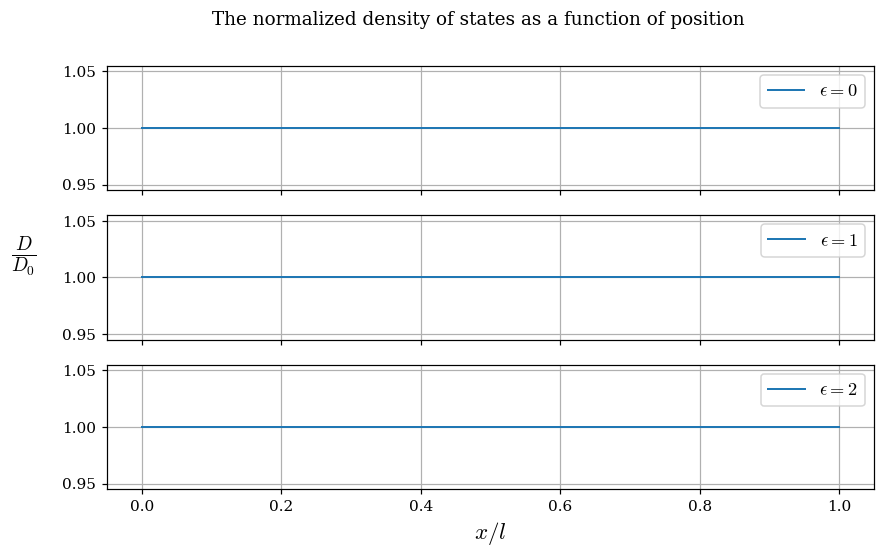

In [31]:
# Plotting
fig2h, axs2h = plt.subplots(3, 1, sharex='all')
for i, sol in enumerate(sol_list):
    x, y = sol
    D = from_solution_to_density_of_states(x, y)
    axs2h[i].plot(x, D, label = f'$\\epsilon={i}$', linewidth = 1.3)
    axs2h[i].legend(fontsize = 12)

axs2h[2].set_xlabel('$x/l$', size = 15)
axs2h[1].set_ylabel('$\\frac{D}{D_0}$', size = 18, rotation = 'horizontal', labelpad = 25)
fig2h.suptitle('The normalized density of states as a function of position')
plt.show()

For all the three energies the density of states is at the normal-state density along the entire length of the metal. In other words, the metal is not affected by the adjacent normal metals at the left and right end. This is consistent with the discussion in exercise 2g.

### 2i)

In [32]:
def bc_residuals_superconductors(v_left, v_right, phi_L, phi_R, epsilon, l):
    t_plus, t_minus = np.atanh(1/(epsilon+0.01j)), np.atanh(-1/(epsilon+0.01j))
    s_plus, s_minus = np.sinh(t_plus), np.sinh(t_minus)
    c_plus, c_minus = np.cosh(t_plus), np.cosh(t_minus)

    a = s_plus/(1+c_plus)
    b = s_minus/(1+c_minus)

    gamma_L = np.array([[0,a],[b,0]]) * np.exp(phi_L*1j)
    gamma_tilde_L = np.array([[0,b],[a,0]]) * np.exp(-phi_L*1j)

    gamma_R = np.array([[0,a],[b,0]]) * np.exp(phi_R*1j)
    gamma_tilde_R = np.array([[0,b],[a,0]]) * np.exp(-phi_R*1j)

    # Compute the residuals at the boundaries
    res = boundary_conditions(v_left, v_right, gamma_L, gamma_tilde_L, gamma_R, gamma_tilde_R, l)

    return res

### 2j)


In [33]:
m = 101
epsilon = 2
l = 1
x = np.linspace(0,l,m)
y = np.zeros((32,m))
phi_L, phi_R = 0, 0

solution = solve_bvp(lambda x,vec: h(x,vec,epsilon), lambda v_left, v_right: bc_residuals_superconductors(v_left, v_right, phi_L, phi_R, epsilon, l), x, y)
x_sol, y_sol = solution.x, solution.y

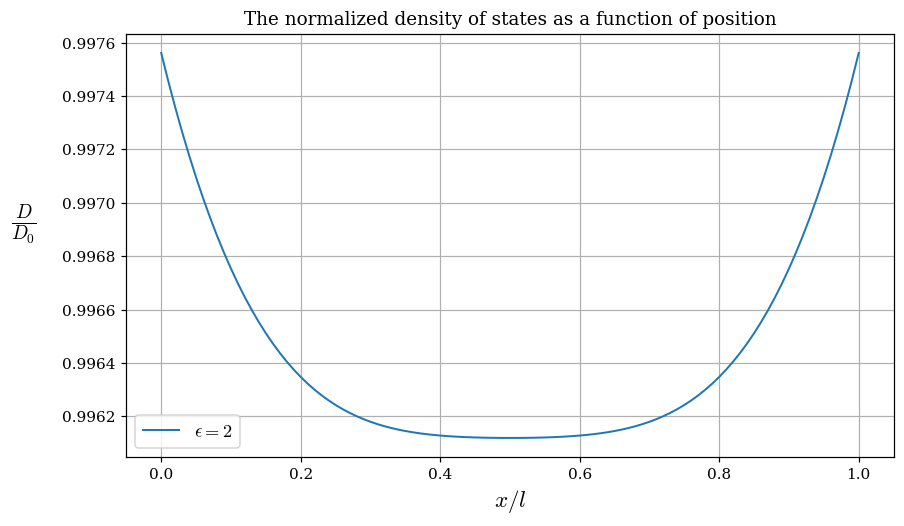

In [34]:
D = from_solution_to_density_of_states(x_sol, y_sol)
plt.plot(x_sol, D, label = f'$\\epsilon={epsilon}$', linewidth = 1.3)
plt.legend(fontsize = 12)

plt.xlabel('$x/l$', size = 15)
plt.ylabel('$\\frac{D}{D_0}$', size = 18, rotation = 'horizontal', labelpad = 25)
plt.title('The normalized density of states as a function of position')
plt.show()

$\epsilon=2$ corresponds to the energy $2|Δ|$ in figure 1. The figure shows that the density of states for a superconductor is approximately equal to $D_0$ at this energy. This means the superconductors interfaced with the normal metal behave similarly to normal metals at this energy. This considered, we expect a similar result as the one obtained in exercise 2h, where the metal is interfaced with normal metals and the resulting state density is the normal-state density. Looking at the plot above, the solution is different from the one in 2h, but the variations in the density of states is very small, and it is generally close to $D_0$, like in 2h.

It is also worth noting that figure 1 shows the density of states $D>D_0$ for $\epsilon=2$ in a superconductor, whereas our solution has  $D<D_0$ at the interfaces $x=0$ and $x=l$. One would expect that $D$ approaches the superconductor's value as $x$ approaches $0$ and $l$. A possible explanation for this is that figure 1 shows the density of states for an isolated superconductor, whereas our superconductors are interfaced with a normal metal, which might reduce the density of states in the superconductor at the interface.

Furthermore, the state density is symmetric about the centre of the metal. This is a logical result since the system itself is symmetric, with equal boundary conditions on the left and right side due to zero phase difference between the superconductors.

### 2k)

In [35]:
m = 101
epsilons = np.linspace(0, 2, 101)
l = [0.1, 0.5, 1, 2]
phi_L, phi_R = 0, 0

# Make a dictionary for storing the solutions
solution_dict_2k = {} # Dictionary for storing solutions
for L in l:
    x = np.linspace(0, L, m)
    y = np.zeros((32, m))

    for j in tqdm.trange(len(epsilons)):
        epsilon = np.flip(epsilons)[j] # Flip the array to start at epsilon=2
        solution = solve_bvp(lambda x,vec: h(x,vec,epsilon), lambda v_left, v_right: bc_residuals_superconductors(v_left, v_right, phi_L, phi_R, epsilon, L), x, y)
        x_sol, y_sol = solution.x, solution.y

        # Store the solution
        label = f'(l, epsilon) = ({L}, {epsilon})'
        solution_dict_2k[label] = (x_sol, y_sol)

        x, y = x_sol, y_sol # Use the solution as the initial guess for the next epsilon

100%|██████████| 101/101 [00:54<00:00,  1.87it/s]


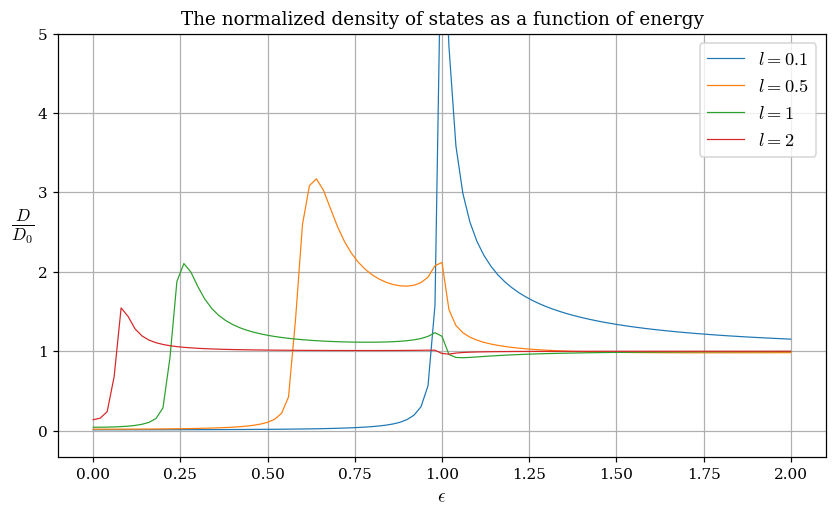

In [36]:
# Plotting
for L in l:
    D_energy = np.zeros((len(epsilons)))
    for j in range(len(epsilons)):
        epsilon = epsilons[j]
        label = f'(l, epsilon) = ({L}, {epsilon})'
        x_sol, y_sol = solution_dict_2k[label]

        # Find the density of states in the middle of the normal metal
        middle = np.argmin(np.abs(x_sol - L/2))
        D_energy[j] = from_solution_to_density_of_states(x_sol, y_sol)[middle]


    plt.plot(epsilons, D_energy, label = f'$l={L}$')

plt.legend(fontsize = 12)
plt.xlabel('$\\epsilon$', size = 12)
plt.ylabel('$\\frac{D}{D_0}$', size = 16, rotation = 'horizontal', labelpad = 10)
plt.ylim(top = 5)
plt.title('The normalized density of states as a function of energy')
plt.show()

The plot shows similarities between the state density of the normal metal and the superconductor as shown in figure 1. A forbidden region appears at low energies; the minigap. This minigap grows wider as $l$ decreases, seemingly approaching $|Δ|$ in width, and getting a more pronounced peak at its border. This makes sense, as the leakage of the superconducting properties has a larger relative effect when the length of the normal metal is smaller.

From looking at the graphs of $l = 0.5, 1$ and $2$, we suspected that a much lower $l$ would be even closer to figure 1, and after checking with $l = 0.1$ that seemed to be the case. For this length, the plot is very similar to the state density in figure 1 for energies above the Fermi energy $(\epsilon>0)$.

### 2l)

In [37]:
def differentiate_Ns(gamma, gamma_tilde, omega, omega_tilde):
    '''
    Calculates the matrices N and N_tilde differentiated wrt. x.
    '''

    N, N_tilde = calculate_Ns(gamma, gamma_tilde)

    dN = N @ ((omega @ gamma_tilde) + (gamma @ omega_tilde)) @ N
    dN_tilde = N_tilde @ ((omega_tilde @ gamma) + (gamma_tilde @ omega)) @ N_tilde

    return dN, dN_tilde

def differentiate_green_function(gamma, gamma_tilde, omega, omega_tilde):
    '''
    Calculates the green function differentiated wrt. x.
    '''
    N, N_tilde = calculate_Ns(gamma, gamma_tilde)
    dN, dN_tilde = differentiate_Ns(gamma, gamma_tilde, omega, omega_tilde)

    dg11 = dN
    dg12 = (N @ omega) + (dN @ gamma)
    dg21 = (-N_tilde @ omega_tilde) - (dN_tilde @ gamma_tilde)
    dg22 = -dN_tilde

    dg = 2 * np.block([[dg11, dg12],[dg21, dg22]])

    return dg

def current_integrand(gamma, gamma_tilde, omega, omega_tilde):

    g = green_function(gamma, gamma_tilde)
    dg = differentiate_green_function(gamma, gamma_tilde, omega, omega_tilde)

    rho_hat = np.diag([1,1,-1,-1])

    product = rho_hat @ ((g @ dg) - (dg @ g))
    trace = np.trace(product)

    j = np.real(trace)

    return j

def from_solution_to_current_integrand(x:np.ndarray, y:np.ndarray)->np.ndarray:
    '''
    Finds the current integrand as a function of position x, given a solution (x,y) from the BVP solver.
    Parameters:
        x: The x-array returned form the BVP solver (solution.x)
        y: The y-array returned form the BVP solver (solution.y)
    Returns:
        The current integrand for each position along x
    '''

    j_array = np.zeros(len(x))
    for i in range(len(x)):
        v = y[:,i]
        gamma, gamma_tilde, omega, omega_tilde = transform_32comp_vector_to_matrices(v)
        j = current_integrand(gamma, gamma_tilde, omega, omega_tilde)
        j_array[i] = j

    return j_array

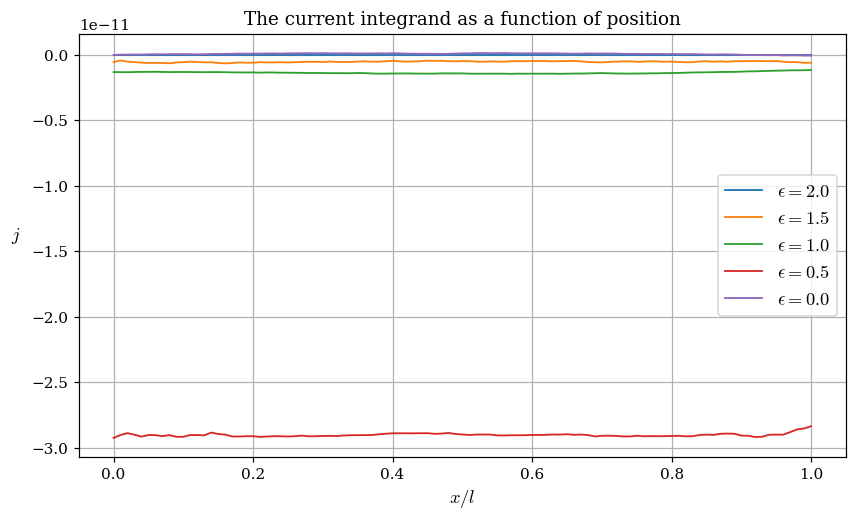

In [38]:
epsilon_list = [2.0, 1.5, 1, 0.5, 0.0]
epsilons = np.linspace(0, 2, 101) # The epsilon values for which we have stored solutions,
                                  # corresponds to the array in exercise 2k

for eps in epsilon_list:
    # Find the element in epsilons closest to the element eps (in case they don't coincide exactly)
    index = np.argmin(np.abs(epsilons-eps))
    epsilon = epsilons[index]

    label = f'(l, epsilon) = ({1}, {epsilon})'
    x, y = solution_dict_2k[label]
    j = from_solution_to_current_integrand(x, y)

    plt.plot(x, j, label = f'$\\epsilon={epsilon}$', linewidth = 1.2)

plt.legend(fontsize = 12)
plt.xlabel('$x/l$', size = 12)
plt.ylabel('$j$', size = 12, rotation = 'horizontal', labelpad = 10)
plt.title('The current integrand as a function of position')
plt.show()

The current integrand $j$ is expected to be zero. While the figure above shows some nonzero $j$, it is at a small order of magnitude and can likely be attributed to innacuracy of the numerically obtained solution. It is curious that $\epsilon=0.5$ shows such a large deviation from the other energies. A possible explanation for this is simply that the differential equation is harder to solve at this energy, making the solution less accurate.

To see if these issues could be explained by innacuracies of the solver, we ran the solver with a lower tolerance—higher accuracy—and found that the current integrand decreased by several orders of magnitude. For this solution the largest deviation was for $\epsilon=1$ instead of $\epsilon=0.5$. This gives us reason to believe that any deviation of $j$ from zero is likely due to inaccuracy of the solver, since the current approaches zero as the solver's accuracy increases. A figure showing the solution obtained using a higher accuracy is shown below.

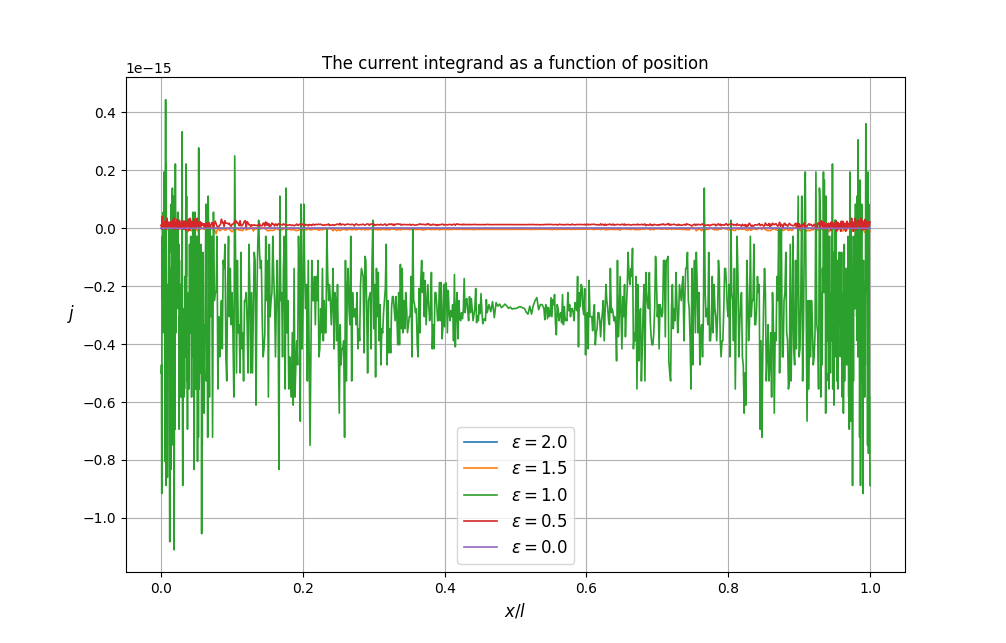

In [39]:
Image("Sol_L_higher_acc_3.png")

### 2m)

In [40]:
m = 101
epsilons = np.linspace(0, 2, 101)
l = 1
phi_L, phi_R = 1, 0
x = np.linspace(0, l, m)
y = np.zeros((32, m))

solution_dict_2m = {}
for i in tqdm.trange(len(epsilons)):
    epsilon = np.flip(epsilons)[i] # Flip the array to start at epsilon=2
    solution = solve_bvp(lambda x,vec: h(x,vec,epsilon), lambda v_left, v_right: bc_residuals_superconductors(v_left, v_right, phi_L, phi_R, epsilon, l), x, y)
    x_sol, y_sol = solution.x, solution.y

    # Store the solution
    label = f'(l, epsilon) = ({l}, {epsilon})'
    solution_dict_2m[label] = (x_sol, y_sol)

    x, y = x_sol, y_sol # Use the solution as the initial guess for the next epsilon

100%|██████████| 101/101 [00:54<00:00,  1.87it/s]


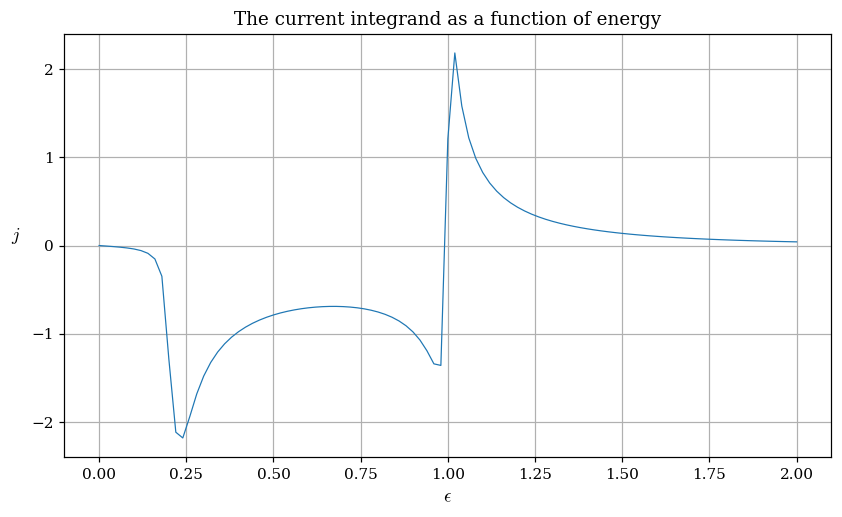

In [41]:
# Plotting
j_array = np.zeros((len(epsilons)))
for i, epsilon in enumerate(epsilons):
    label = f'(l, epsilon) = ({l}, {epsilon})'
    x, y = solution_dict_2m[label]

    # Take the solution in the middle of the normal metal
    middle = np.argmin(np.abs(x - l/2))
    j_array[i] = from_solution_to_current_integrand(x, y)[middle]

plt.plot(epsilons, j_array)
plt.xlabel('$\\epsilon$', size = 12)
plt.ylabel('$j$', size = 12, rotation = 'horizontal', labelpad = 10)
plt.title('The current integrand as a function of energy')
plt.show()

As opposed to in exercise 2l, the figure above shows a nonzero current integrand for several energies, as well as a systematic variation between energies. The exact shape of the graph is difficult to interpret. One thing to note is that the current integrand approaches zero at higher energies, for which the leakage of superconducting properties is minimal. The figure below shows the current integrand as a function of position for the same energies as in exercise 2l, and it is clear that the current is conserved over position.

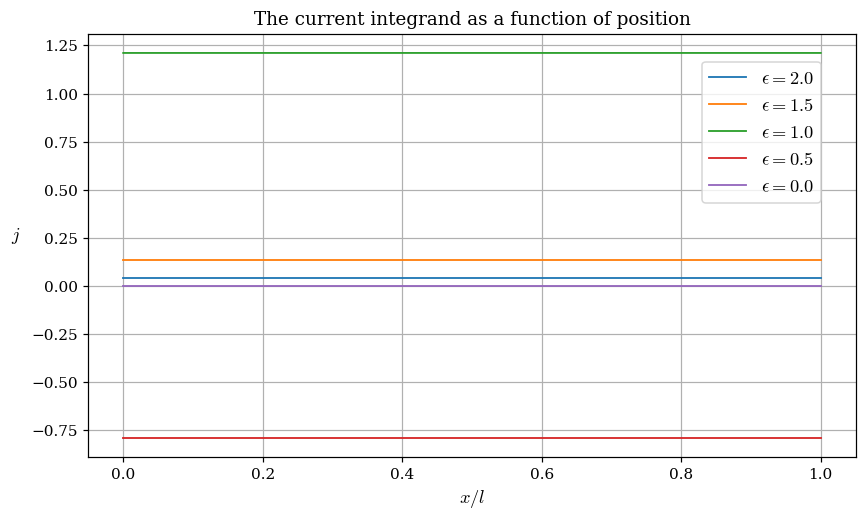

In [42]:
# Plotting to see if the current is x-dependent
epsilon_list = [2.0, 1.5, 1, 0.5, 0.0]
epsilons = np.linspace(0, 2, 101) # The epsilon values for which we have stored solutions,
                                  # corresponds to the array in exercise 2m

for eps in epsilon_list:
    # Find the element in epsilons closest to the element eps
    index = np.argmin(np.abs(epsilons-eps))
    epsilon = epsilons[index]

    label = f'(l, epsilon) = ({1}, {epsilon})'
    x, y = solution_dict_2m[label]
    j = from_solution_to_current_integrand(x, y)

    plt.plot(x, j, label = f'$\\epsilon={epsilon}$', linewidth = 1.2)

plt.legend(fontsize = 12, loc = (0.8, 0.6))
plt.xlabel('$x/l$', size = 12)
plt.ylabel('$j$', size = 12, rotation = 'horizontal', labelpad = 10)
plt.title('The current integrand as a function of position')
plt.show()

### 2n)

In [43]:
m = 101
l = 1
epsilons = np.linspace(0, 2, 101)
x = np.linspace(0, l, m)
y = np.zeros((32, m))

phi_L_list = np.linspace(0, 2*np.pi, 20)
phi_R = 0

solution_dict_2n = {} # Dictionary for storing solutions
for phi_L in phi_L_list:
    for i in tqdm.trange(len(epsilons)):
        epsilon = np.flip(epsilons)[i] # Flip the array to start at epsilon=2
        solution = solve_bvp(lambda x,vec: h(x,vec,epsilon), lambda v_left, v_right: bc_residuals_superconductors(v_left, v_right, phi_L, phi_R, epsilon, l), x, y)
        x_sol, y_sol = solution.x, solution.y

        # Store the solution
        label = f'(l, epsilon, phase_diff) = ({l}, {epsilon}, {phi_L})'
        solution_dict_2n[label] = (x_sol, y_sol)

        x, y = x_sol, y_sol # Use the solution as the initial guess for the next epsilon

100%|██████████| 101/101 [00:53<00:00,  1.87it/s]


In [44]:
supercurrent_function_of_phase_diff = np.zeros(len(phi_L_list))
for n, phi_L in enumerate(phi_L_list):
    j_array = np.zeros(len(epsilons))
    for i, epsilon in enumerate(epsilons):
        label = f'(l, epsilon, phase_diff) = ({l}, {epsilon}, {phi_L})'
        x, y = solution_dict_2n[label]

        # We find the current integrand at x=l/2. Since the integrand is conserved over x, the choice of x is unimportant.
        middle = np.argmin(np.abs(x - l/2))
        j_array[i] = from_solution_to_current_integrand(x, y)[middle]

    # Integrate over epsilon=0 to 2 to find the supercurrent at x = l/2.
    supercurrent = -simpson(j_array, epsilons)
    supercurrent_function_of_phase_diff[n] = supercurrent

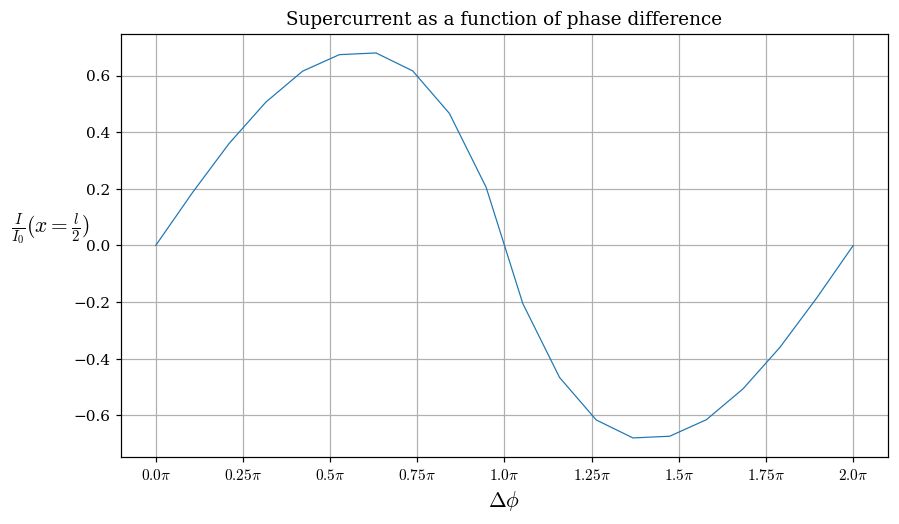

In [45]:
plt.plot(phi_L_list, supercurrent_function_of_phase_diff)
plt.ylabel('$\\frac{I}{I_0}(x=\\frac{l}{2})$', size = 14, labelpad = 15, rotation = 'horizontal')
plt.xlabel('$\\Delta \\phi$', size = 14)
ticks = np.arange(0, 2*np.pi + np.pi/4, np.pi/4)
labels = [f'${num/np.pi}\\pi$' for num in ticks]
plt.xticks(ticks, labels)
plt.title('Supercurrent as a function of phase difference')
plt.show()

The current has a sine-like structure with roots at $\Delta \phi = 0, \pi$ and $2\pi$, which means that when the phases are parallel or anti parallel, the current becomes zero. In addition, we can observe that, as with the sine function, the current is positive when $\Delta \phi < \pi$ and negative when $\Delta \phi > \pi$.

We note that $I < I_0$ for all $\Delta \phi$, but without more information about $I_0$ it's hard to comment on the magnitude of the current. The main take-away is that the current is clearly dependent on the phase difference between the superconductors, and is zero when there is no phase difference.